<a href="https://colab.research.google.com/github/hanmtay/IntroToAI_A2/blob/main/section1_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hanmtay/IntroToAI_A2.git
%cd IntroToAI_A2

Cloning into 'IntroToAI_A2'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 57 (delta 28), reused 36 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 163.34 KiB | 1.58 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/IntroToAI_A2


imported libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

loading in data

In [3]:
df = pd.read_csv('a2_Hannah_Taylor_40443054/40443054_features.csv')

spliting into living category

In [4]:
#living = 1, non-living = 0
living_classes = ['cherry', 'banana', 'lemon', 'tree']
df['living'] = df['label'].isin(living_classes).astype(int)

features chosen

In [5]:
my_features = ['rows_with_1', 'cols_with_2', 'eyes', 'hollowness']

Task 1.1

Confusion Matrix:
 [[10  2]
 [ 0 12]]
Accuracy: 0.9167
True Positive Rate (Recall): 1.0000
False Positive Rate: 0.1667
Precision: 0.8571
F1-Score: 0.9231
    Actual_Class  Living_Probability  Prediction_at_0.5
60         lemon            0.983226                  1
16        cherry            0.960843                  1
50      golfclub            0.149527                  0
95          tree            0.796362                  1
39      envelope            0.047350                  0
110         wine            0.000486                  0
75        pencil            0.840911                  1
91          tree            0.865462                  1
21        cherry            0.985219                  1
59         lemon            0.998618                  1


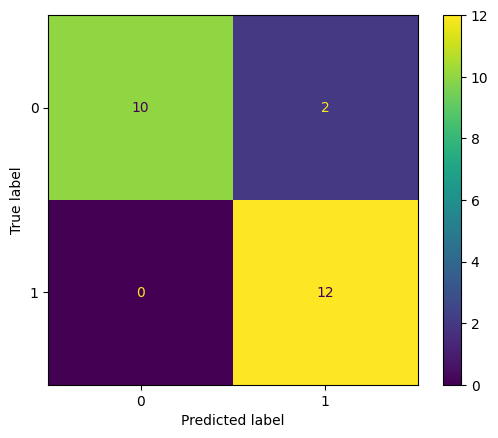

In [6]:
#stratify the test set
train_df, test_df = train_test_split(
    df,
    test_size=24,
    stratify=df['label'],
    random_state=42
)

X_train = train_df[my_features]
y_train = train_df['living']
X_test = test_df[my_features]
y_test = test_df['living']

# 5. Fit Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

#decision threshold is automatically 0.5 (https://www.geeksforgeeks.org/data-science/what-is-the-default-threshold-in-sklearn-logistic-regression/)
y_pred = model.predict(X_test)

#probability
y_probs = model.predict_proba(X_test)

#second column is living
living_probabilities = y_probs[:, 1]

#able to see the actual items and the repsective probabilities
results_df = pd.DataFrame({
    'Actual_Class': test_df['label'],
    'Living_Probability': living_probabilities,
    'Prediction_at_0.5': y_pred
})

cm = confusion_matrix(y_test, y_pred)
#positions got from slides
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
tpr = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr = fp / (fp + tn)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy:.4f}")
print(f"True Positive Rate (Recall): {tpr:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")

print(results_df.head(10))

#from: (https://www.w3schools.com/python/python_ml_confusion_matrix.asp#:~:text=It%20is%20a%20table%20that,see%20which%20predictions%20are%20wrong.)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.savefig('confusionMatrix.png')
plt.show()

Task 1.2

Confusion Matrix:
[[50  6]
 [ 2 54]]
Cross-validated Accuracy: 0.9286
True Positive Rate (Recall): 0.9643
False Positive Rate: 0.1071
Precision: 0.9000
F1-Score: 0.9310
  Actual_Class  Living_Probability  Prediction_at_0.5
0       banana            0.880215                  1
1       banana            0.998413                  1
2       banana            0.997476                  1
3       banana            0.979805                  1
4       banana            0.999828                  1
5       banana            0.995303                  1
6       banana            0.997066                  1
7       banana            0.906368                  1
8       banana            0.023107                  0
9       banana            0.999937                  1


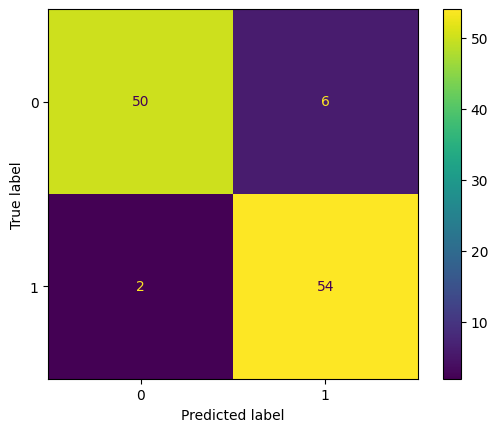

In [9]:
x = df[my_features]
y = df['living']

model = LogisticRegression()
model.fit(x, y)
kfolds = 7
#stratified k fold found in: https://www.w3schools.com/python/python_ml_cross_validation.asp
cv = StratifiedKFold(n_splits=kfolds, shuffle=True, random_state=42)

# 4. Perform 7-fold Cross-validation
# This gets predicted labels for all 112 items using CV folds
y_predCV = cross_val_predict(model, x, y, cv=cv)

#probability
y_probsCV = model.predict_proba(x)

#second column is living
living_probabilitiesCV = y_probs[:, 1]

#able to see the actual items and the repsective probabilities
results_df = pd.DataFrame({
    'Actual_Class': df['label'],
    'Living_Probability': living_probabilitiesCV,
    'Prediction_at_0.5': y_predCV
})

# 5. Calculate Metrics
cm = confusion_matrix(y, y_predCV)
tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

accuracy = accuracy_score(y, y_predCV)
precision = precision_score(y, y_predCV)
recall = recall_score(y, y_predCV)
f1 = f1_score(y, y_predCV)
fpr = fp / (fp + tn)

# 6. Display Results
print(f"Confusion Matrix:\n{cm}")
print(f"Cross-validated Accuracy: {accuracy:.4f}")
print(f"True Positive Rate (Recall): {recall:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1:.4f}")

print(results_df.head(10))

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])

cm_display.plot()
plt.savefig('confusionMatrixCV.png')
plt.show()

Task 1.3

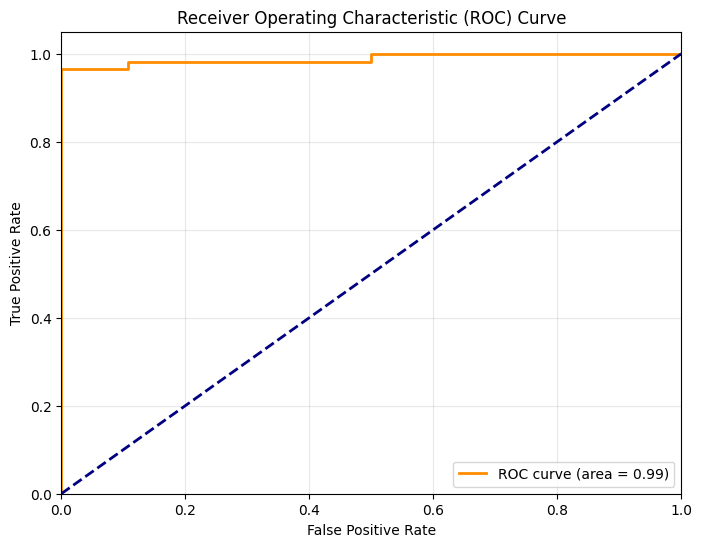

Area Under the Curve (AUC): 0.9892


In [10]:
fpr_roc, tpr_roc, thresholds = roc_curve(y, living_probabilitiesCV)
roc_auc = auc(fpr_roc, tpr_roc)

plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('ROC_curve.png')
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")